In [1]:
import pandas as pd
import os

import plt
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [2]:
folder = "data/excel_files"

file_paths = [os.path.join(folder, f) for f in os.listdir(folder)]

df = pd.DataFrame()
for f in tqdm(file_paths):
    df = pd.concat([df, pd.read_excel(f, sheet_name="DATA", header=5)], ignore_index=True)

df = df[~df['EIC-код'].isin(['Grand Total', 'Загальний підсумок'])].copy()

static_data_dict = pd.read_excel("data/raw/8month2025.xlsx", sheet_name="Dict")

eic_code_to_missing_coords = {
    "62Z0602349894257": [48.763904006776954, 28.077456990197557],
    "62Z6035944504754": [49.153510259625534, 23.049801982501872],
    "62Z8888861892130": [48.309249416757545, 25.11895645420284],
    "62Z1209368438999": [49.78531388363913, 24.927028292321978],
    "62Z1771663109656": [49.453445499775405, 23.020911411362146],
    "62Z2532379651825": [49.29362429838761, 23.41030049170128],
    "62Z3261331410025": [49.56421176098104, 23.304357225434188],
    "62Z3627036877597": [48.51882104530565, 28.760435421364264],
    "62Z5422632680702": [50.22822399875523, 24.83726310970472],
    "62Z0763594350330": [49.369735771908296, 23.47527668624802],
    "62Z7029546479880": [49.77948499692157, 24.013408048459073],
    "62Z7072263538637": [49.86242688799433, 24.062926768794956],
    "62Z7766151236986": [50.46762760936502, 24.26123769025777],
    "62Z5064314448909": [48.149046045899055, 23.322957181272095],
    "62Z9342951787758": [49.28552561066835, 23.534192240667057],
    "62Z8521105012164": [48.36054435942602, 29.536275478873062],
    "62Z1142387881356": [49.76402754584019, 31.39902598856454],
    "62Z6624735969589": [48.94419405940688, 24.149295411716132],
    "62Z5956494916290": [49.95178196130912, 25.31699531547816],
    "62Z0717322121288": [48.207039717684104, 23.522199099176],
    "62Z568600499251K": [49.74638889010666, 31.486251700927244],
}

lat_map = {k: v[0] for k, v in eic_code_to_missing_coords.items()}
lon_map = {k: v[1] for k, v in eic_code_to_missing_coords.items()}

static_data_dict["GPS-координати - Широта"] = (
    static_data_dict["GPS-координати - Широта"]
    .fillna(static_data_dict["EIC-код"].map(lat_map))
)

static_data_dict["GPS-координати - Довгота"] = (
    static_data_dict["GPS-координати - Довгота"]
    .fillna(static_data_dict["EIC-код"].map(lon_map))
)

df = df.merge(static_data_dict, on='EIC-код', how='left', suffixes=('', '_dict'))
df

  0%|          | 0/10 [00:00<?, ?it/s]

,EIC-код,Група,Дата,Year,Month,Day,Hour,Sum of кВт,Average of Ціна розподілу ЕЕ грн. без ПДВ/кВт*год,Average of Ціна ЕЕ грн. без ПДВ/кВт*год,Унікод,АЗС,Тип,Область,Адреса,GPS-координати - Широта,GPS-координати - Довгота,ОСР код,ОСР опис
0,62Z0008583037334,Б,2024-09-01,2024.0,9.0,1.0,1.0,19.264333,2.15221,5.697900,40312900,АЗС_29,ОККО-комплекс,Закарпатська,"Ужгородський р-н, с. Соломоново, автодорога Ки...",48.442430,22.192190,MGA-00700,Ужгород
1,62Z0008583037334,Б,2024-09-01,2024.0,9.0,1.0,2.0,16.892233,2.15221,5.697900,40312900,АЗС_29,ОККО-комплекс,Закарпатська,"Ужгородський р-н, с. Соломоново, автодорога Ки...",48.442430,22.192190,MGA-00700,Ужгород
2,62Z0008583037334,Б,2024-09-01,2024.0,9.0,1.0,3.0,15.382714,2.15221,5.697900,40312900,АЗС_29,ОККО-комплекс,Закарпатська,"Ужгородський р-н, с. Соломоново, автодорога Ки...",48.442430,22.192190,MGA-00700,Ужгород
3,62Z0008583037334,Б,2024-09-01,2024.0,9.0,1.0,4.0,15.598360,2.15221,5.697900,40312900,АЗС_29,ОККО-комплекс,Закарпатська,"Ужгородський р-н, с. Соломоново, автодорога Ки...",48.442430,22.192190,MGA-00700,Ужгород
4,62Z0008583037334,Б,2024-09-01,2024.0,9.0,1.0,5.0,14.735777,2.15221,5.697900,40312900,АЗС_29,ОККО-комплекс,Закарпатська,"Ужгородський р-н, с. Соломоново, автодорога Ки...",48.442430,22.192190,MGA-00700,Ужгород
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5454708,62Z9997819406173,Б,2025-08-31,2025.0,8.0,31.0,20.0,22.540932,1.76339,5.447321,40116500,АЗС_65,ОККО-міська,Львівська,"м. Львів, вул. Зелена, 283",49.800007,24.068964,MGA-00900,Львів
5454709,62Z9997819406173,Б,2025-08-31,2025.0,8.0,31.0,21.0,24.207382,1.76339,5.447321,40116500,АЗС_65,ОККО-міська,Львівська,"м. Львів, вул. Зелена, 283",49.800007,24.068964,MGA-00900,Львів
5454710,62Z9997819406173,Б,2025-08-31,2025.0,8.0,31.0,22.0,25.211150,1.76339,5.447321,40116500,АЗС_65,ОККО-міська,Львівська,"м. Львів, вул. Зелена, 283",49.800007,24.068964,MGA-00900,Львів
5454711,62Z9997819406173,Б,2025-08-31,2025.0,8.0,31.0,23.0,22.579913,1.76339,5.447321,40116500,АЗС_65,ОККО-міська,Львівська,"м. Львів, вул. Зелена, 283",49.800007,24.068964,MGA-00900,Львів


In [3]:
df['Дата'] = pd.to_datetime(df['Дата'], errors='coerce')
df['Дата'] = df['Дата'] + pd.to_timedelta(df['Hour'].fillna(0), unit='h')
df

,EIC-код,Група,Дата,Year,Month,Day,Hour,Sum of кВт,Average of Ціна розподілу ЕЕ грн. без ПДВ/кВт*год,Average of Ціна ЕЕ грн. без ПДВ/кВт*год,Унікод,АЗС,Тип,Область,Адреса,GPS-координати - Широта,GPS-координати - Довгота,ОСР код,ОСР опис
0,62Z0008583037334,Б,2024-09-01 01:00:00,2024.0,9.0,1.0,1.0,19.264333,2.15221,5.697900,40312900,АЗС_29,ОККО-комплекс,Закарпатська,"Ужгородський р-н, с. Соломоново, автодорога Ки...",48.442430,22.192190,MGA-00700,Ужгород
1,62Z0008583037334,Б,2024-09-01 02:00:00,2024.0,9.0,1.0,2.0,16.892233,2.15221,5.697900,40312900,АЗС_29,ОККО-комплекс,Закарпатська,"Ужгородський р-н, с. Соломоново, автодорога Ки...",48.442430,22.192190,MGA-00700,Ужгород
2,62Z0008583037334,Б,2024-09-01 03:00:00,2024.0,9.0,1.0,3.0,15.382714,2.15221,5.697900,40312900,АЗС_29,ОККО-комплекс,Закарпатська,"Ужгородський р-н, с. Соломоново, автодорога Ки...",48.442430,22.192190,MGA-00700,Ужгород
3,62Z0008583037334,Б,2024-09-01 04:00:00,2024.0,9.0,1.0,4.0,15.598360,2.15221,5.697900,40312900,АЗС_29,ОККО-комплекс,Закарпатська,"Ужгородський р-н, с. Соломоново, автодорога Ки...",48.442430,22.192190,MGA-00700,Ужгород
4,62Z0008583037334,Б,2024-09-01 05:00:00,2024.0,9.0,1.0,5.0,14.735777,2.15221,5.697900,40312900,АЗС_29,ОККО-комплекс,Закарпатська,"Ужгородський р-н, с. Соломоново, автодорога Ки...",48.442430,22.192190,MGA-00700,Ужгород
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5454708,62Z9997819406173,Б,2025-08-31 20:00:00,2025.0,8.0,31.0,20.0,22.540932,1.76339,5.447321,40116500,АЗС_65,ОККО-міська,Львівська,"м. Львів, вул. Зелена, 283",49.800007,24.068964,MGA-00900,Львів
5454709,62Z9997819406173,Б,2025-08-31 21:00:00,2025.0,8.0,31.0,21.0,24.207382,1.76339,5.447321,40116500,АЗС_65,ОККО-міська,Львівська,"м. Львів, вул. Зелена, 283",49.800007,24.068964,MGA-00900,Львів
5454710,62Z9997819406173,Б,2025-08-31 22:00:00,2025.0,8.0,31.0,22.0,25.211150,1.76339,5.447321,40116500,АЗС_65,ОККО-міська,Львівська,"м. Львів, вул. Зелена, 283",49.800007,24.068964,MGA-00900,Львів
5454711,62Z9997819406173,Б,2025-08-31 23:00:00,2025.0,8.0,31.0,23.0,22.579913,1.76339,5.447321,40116500,АЗС_65,ОККО-міська,Львівська,"м. Львів, вул. Зелена, 283",49.800007,24.068964,MGA-00900,Львів


/var/folders/5w/bchvy66s6vbgncfkws1skvf40000gp/T/ipykernel_3202/854375379.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


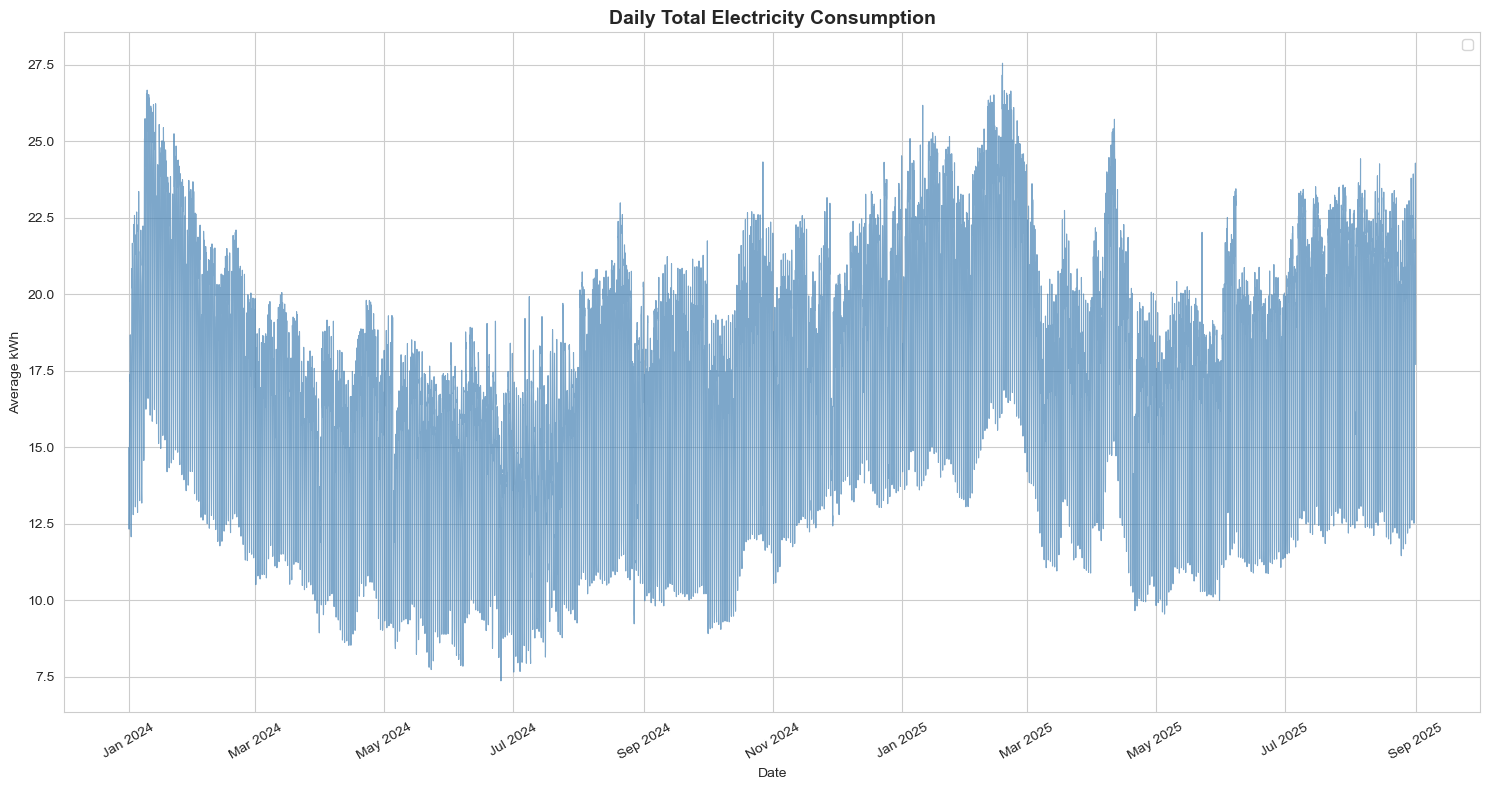

In [4]:
# ── Daily total consumption ────────────────────────────────────────────────
daily = df.groupby("Дата")["Sum of кВт"].mean().reset_index()
daily.columns = ['date', 'avg_kwh']

fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(daily['date'], daily['avg_kwh'], linewidth=0.8, color='steelblue', alpha=0.7)
# ax.plot(daily['date'], daily['total_kwh'].rolling(7).mean(), color='red',
        # linewidth=2, label='7-day rolling mean')
ax.set_title('Daily Total Electricity Consumption', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Average kWh')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# global time bounds
start_time = df['Дата'].min()
end_time = df['Дата'].max()

# station-level first and last observation
station_bounds = df.groupby('EIC-код')['Дата'].agg(['min', 'max'])

# check full boundary coverage
station_bounds['full_span'] = (
    (station_bounds['min'] <= start_time) &
    (station_bounds['max'] >= end_time)
)

# percentage of stations with full span coverage
full_span_pct = station_bounds['full_span'].mean() * 100

print(f"Dataset range        : {start_time} → {end_time}")
print(f"Stations full span   : {full_span_pct:.2f}%")
print(f"Stations missing span: {(~station_bounds['full_span']).sum()}")

Dataset range        : 2024-01-01 01:00:00 → 2025-09-01 00:00:00
Stations full span   : 83.94%
Stations missing span: 66


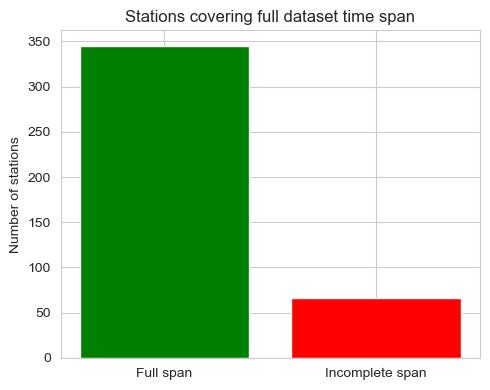

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.bar(
    ['Full span', 'Incomplete span'],
    [station_bounds['full_span'].sum(), (~station_bounds['full_span']).sum()],
    color=['green', 'red']
)

ax.set_title('Stations covering full dataset time span')
ax.set_ylabel('Number of stations')

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

start_time = df['Дата'].min()
end_time = df['Дата'].max()

station_bounds = df.groupby('EIC-код')['Дата'].agg(['min', 'max']).reset_index()
station_bounds.columns = ['EIC', 'start', 'end']

# incomplete stations only
incomplete = station_bounds[
    (station_bounds['start'] > start_time) |
    (station_bounds['end'] < end_time)
].copy()

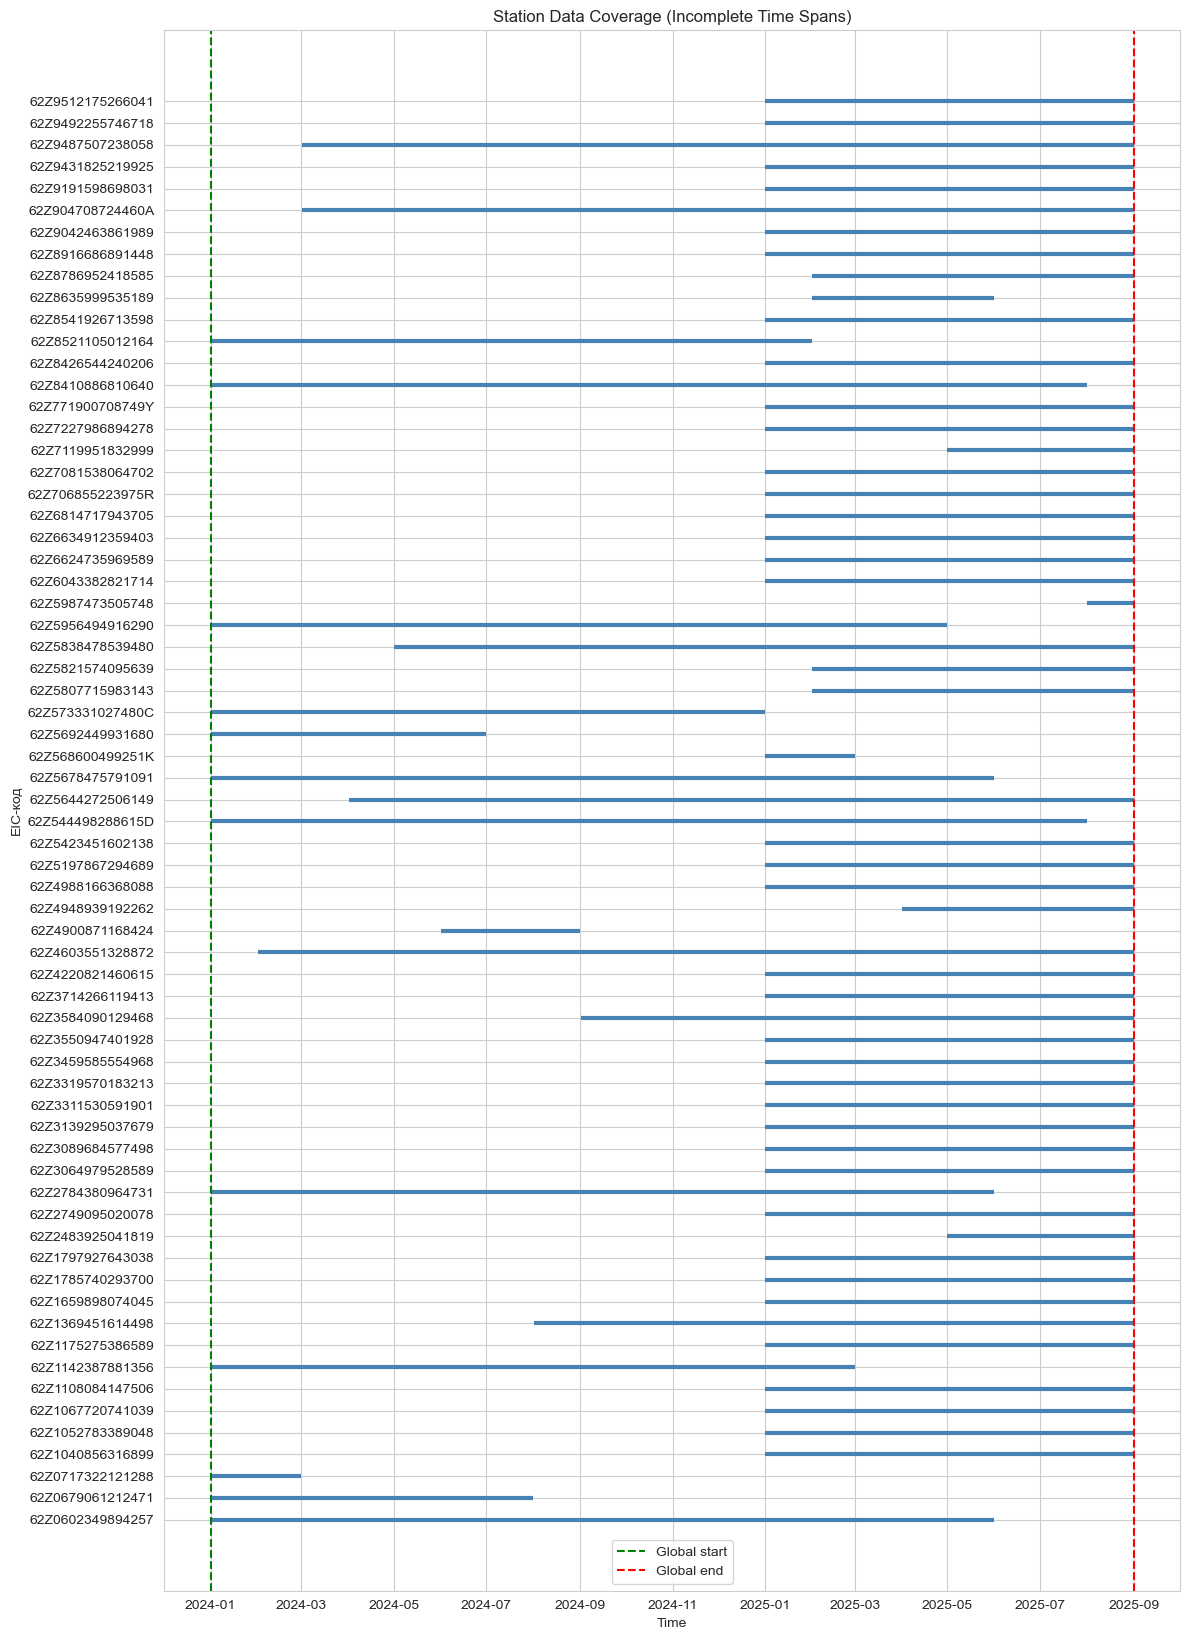

In [8]:
fig, ax = plt.subplots(figsize=(12, max(6, len(incomplete) * 0.25)))

for i, row in enumerate(incomplete.itertuples()):
    ax.hlines(
        y=i,
        xmin=row.start,
        xmax=row.end,
        color='steelblue',
        linewidth=3
    )

# full expected range
ax.axvline(start_time, color='green', linestyle='--', label='Global start')
ax.axvline(end_time, color='red', linestyle='--', label='Global end')

ax.set_yticks(range(len(incomplete)))
ax.set_yticklabels(incomplete['EIC'])
ax.set_title('Station Data Coverage (Incomplete Time Spans)')
ax.set_xlabel('Time')
ax.set_ylabel('EIC-код')

ax.legend()
plt.tight_layout()
plt.show()

In [9]:
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import pandas as pd


def plot_forecast(eval_df, eic_code, start_dt=None, end_dt=None):
    df = eval_df.copy()
    df = df[df['EIC-код'] == eic_code].sort_values("Дата")

    if df.empty:
        raise ValueError(f"No data for EIC code: {eic_code!r}")

    if start_dt is not None:
        df = df[df["Дата"] >= pd.Timestamp(start_dt)]

    if end_dt is not None:
        df = df[df["Дата"] <= pd.Timestamp(end_dt)]

    if df.empty:
        raise ValueError("No data in the specified Дата range.")

    fig, ax = plt.subplots(figsize=(16, 7))

    # main line
    ax.plot(
        df["Дата"],
        df['Sum of кВт'],
        color="steelblue",
        linewidth=1.5,
        label="Consumption"
    )

    # subtle area fill (matches modern energy plots)
    ax.fill_between(
        df["Дата"],
        df['Sum of кВт'],
        color="steelblue",
        alpha=0.15
    )

    # labels
    ax.set_xlabel("Дата")
    ax.set_ylabel("Sum of кВт")

    ax.set_title(
        f"{eic_code}  ({df['Дата'].min().date()} – {df['Дата'].max().date()})",
        pad=12
    )

    # force y-axis baseline at 0
    ax.set_ylim(bottom=0)

    # date formatting
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))

    # styling: no grid, no frame
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    # cleaner ticks
    ax.tick_params(axis='both', which='both', length=0)

    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

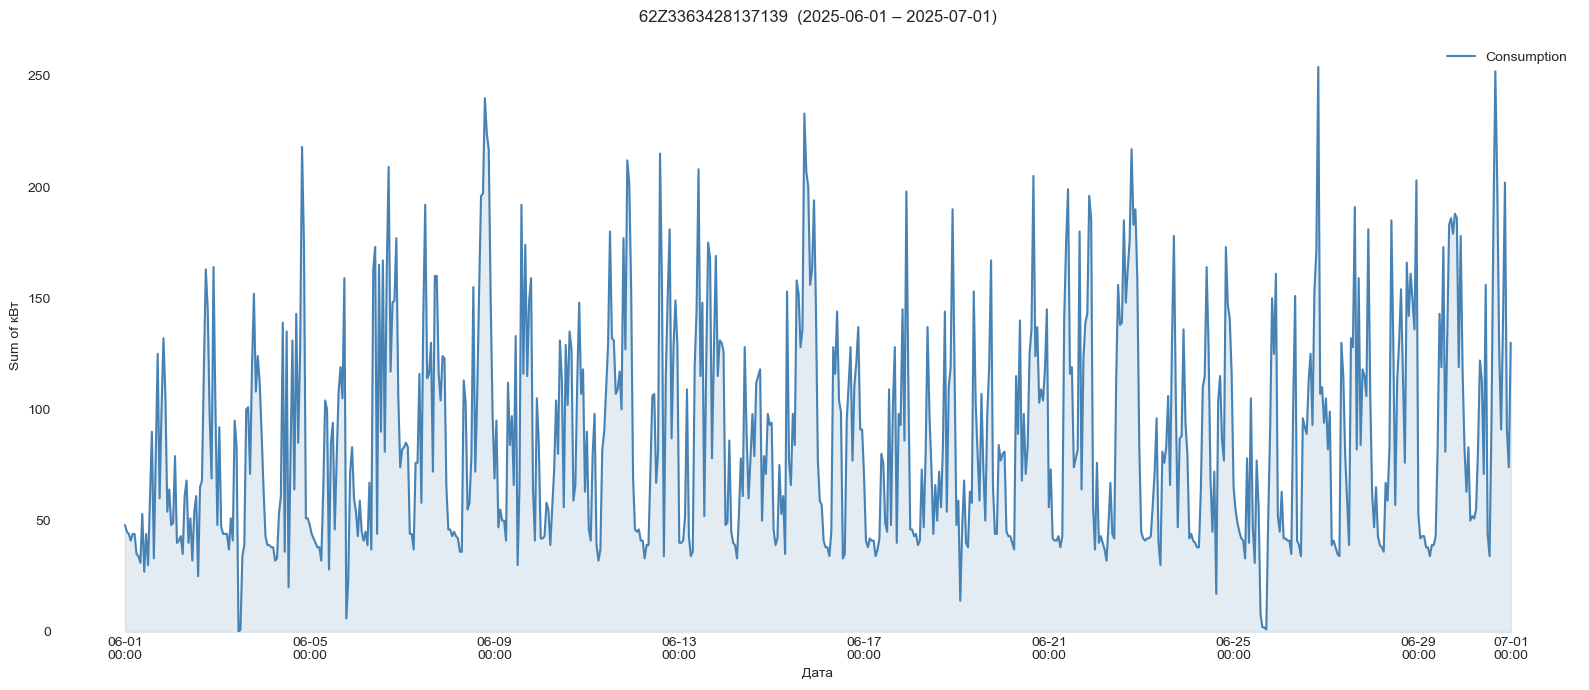

In [10]:
plot_forecast(df,  eic_code="62Z3363428137139", start_dt="2025-06-01", end_dt="2025-07-01")

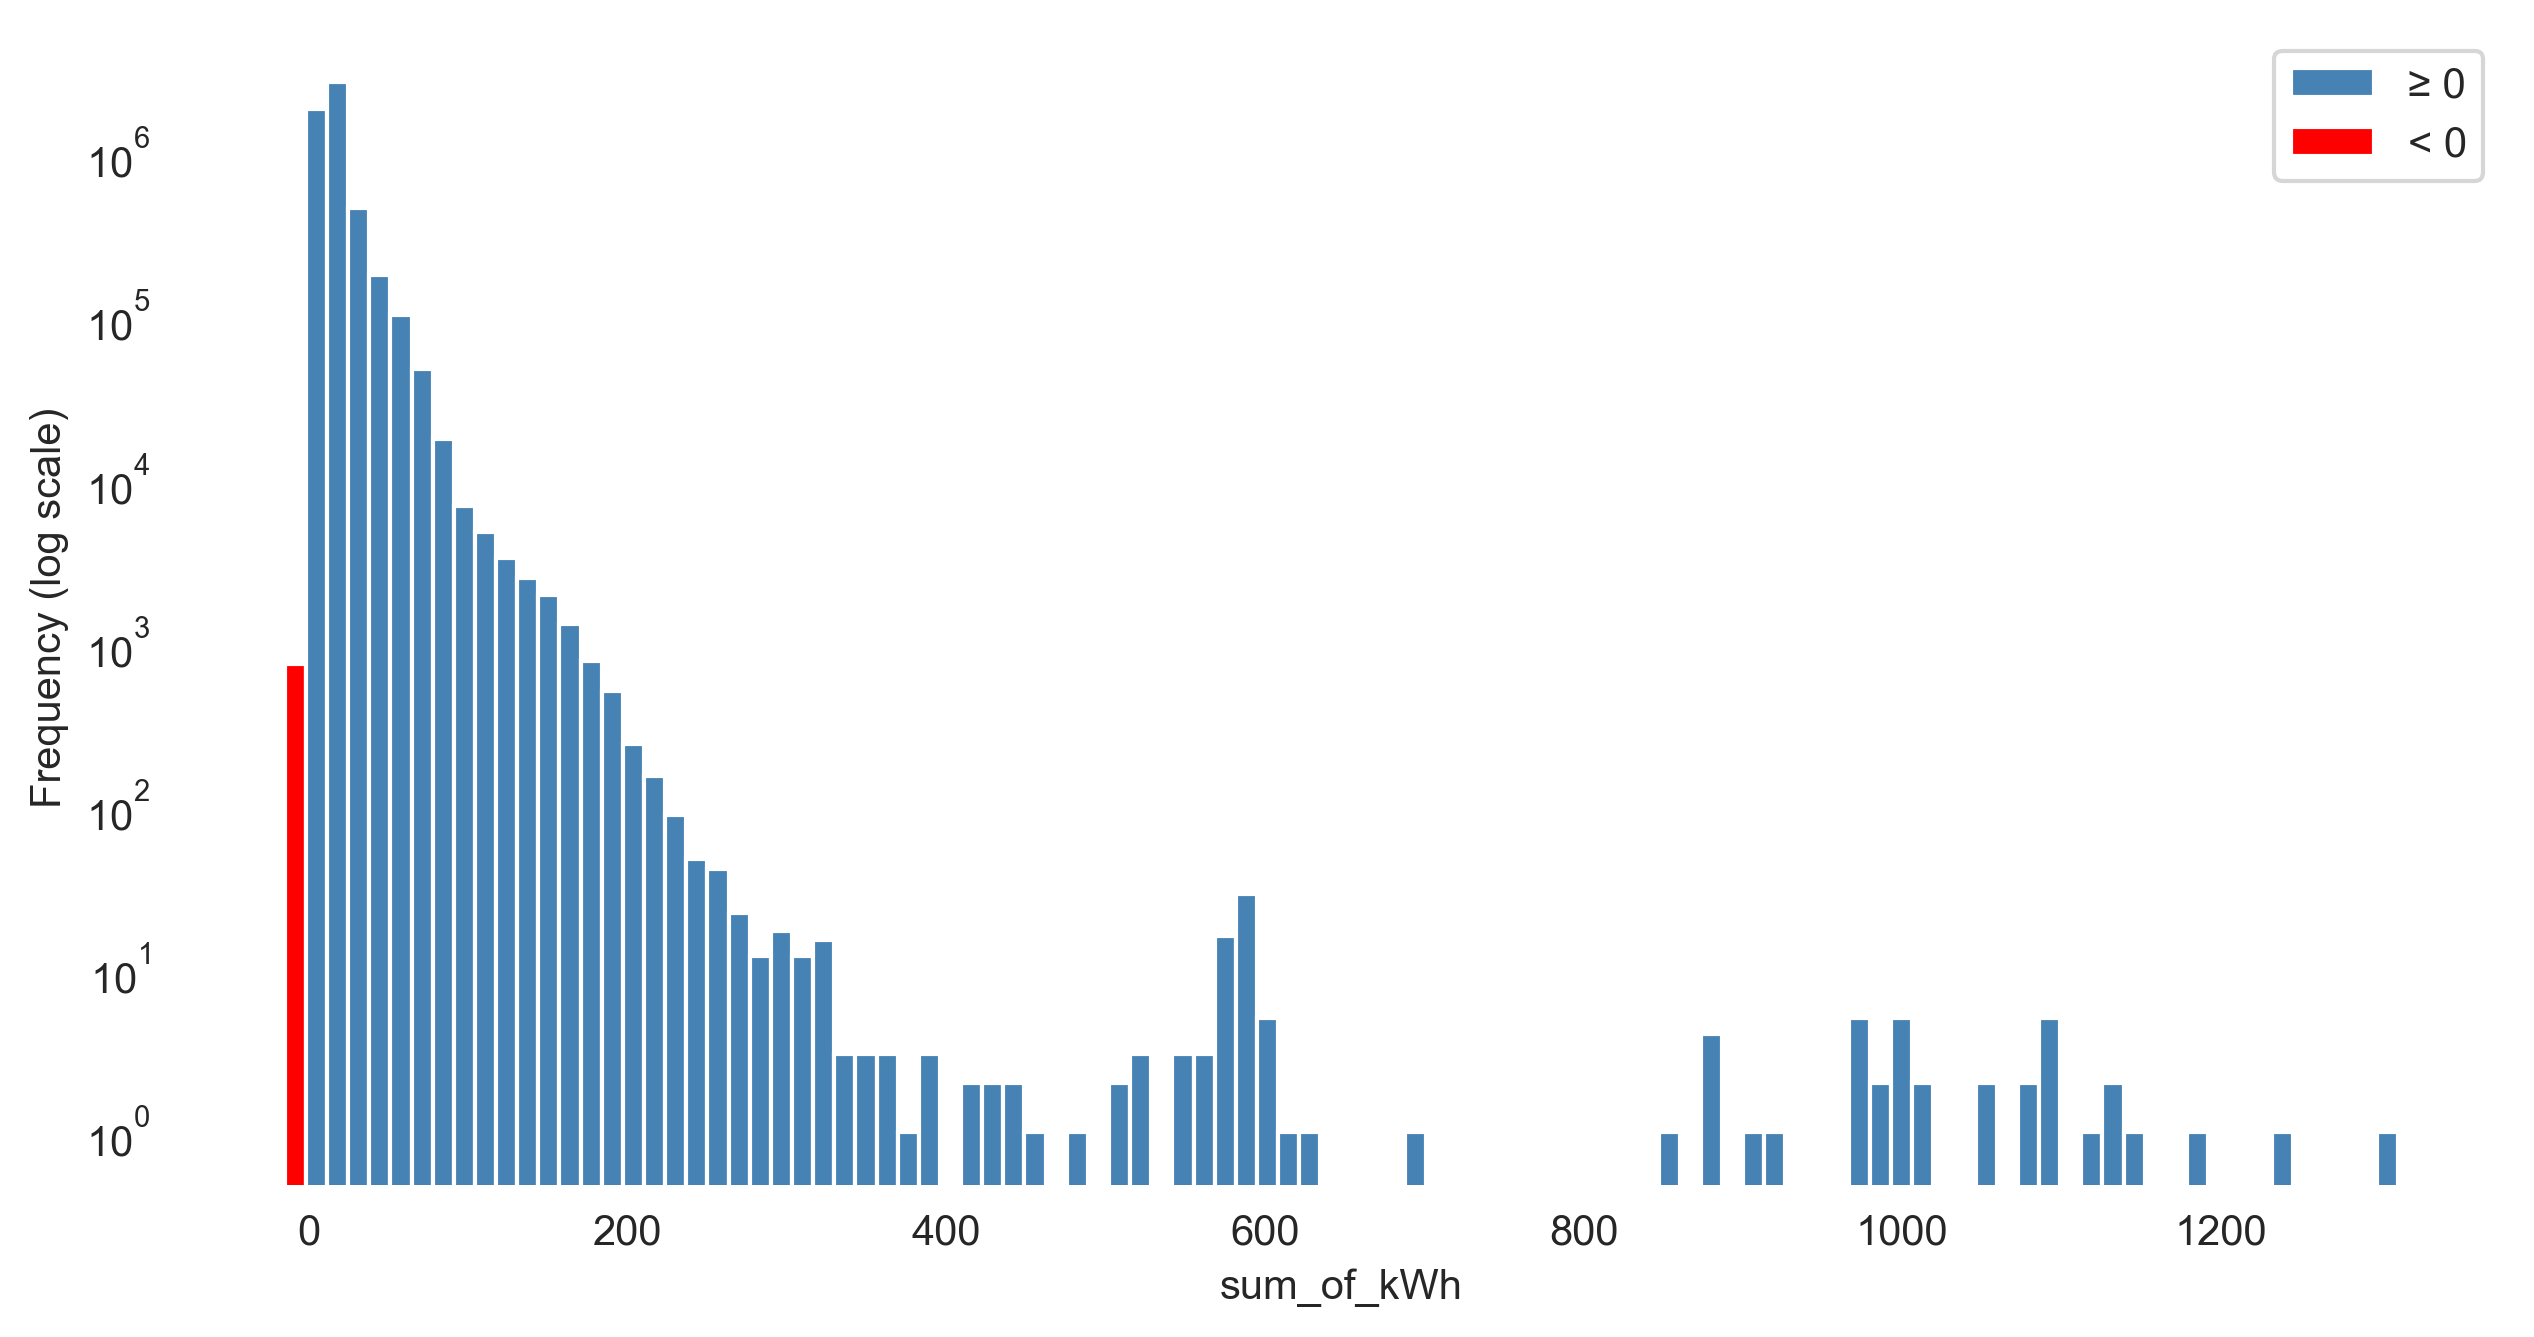

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

data = df['Sum of кВт'].dropna()

counts, bins = np.histogram(data, bins=100)
centers = (bins[:-1] + bins[1:]) / 2
widths = np.diff(bins)

colors = ['red' if x < 0 else 'steelblue' for x in centers]

plt.figure(figsize=(10, 5), dpi=300)
plt.bar(centers, counts, width=widths, color=colors, align='center')

# log scale
plt.yscale('log')

# remove grid
plt.grid(False)

# remove border
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# axis labels
plt.xlabel('sum_of_kWh')
plt.ylabel('Frequency (log scale)')

# legend
legend_elements = [
    Patch(facecolor='steelblue', label='≥ 0'),
    Patch(facecolor='red', label='< 0')
]
plt.legend(handles=legend_elements)

plt.show()

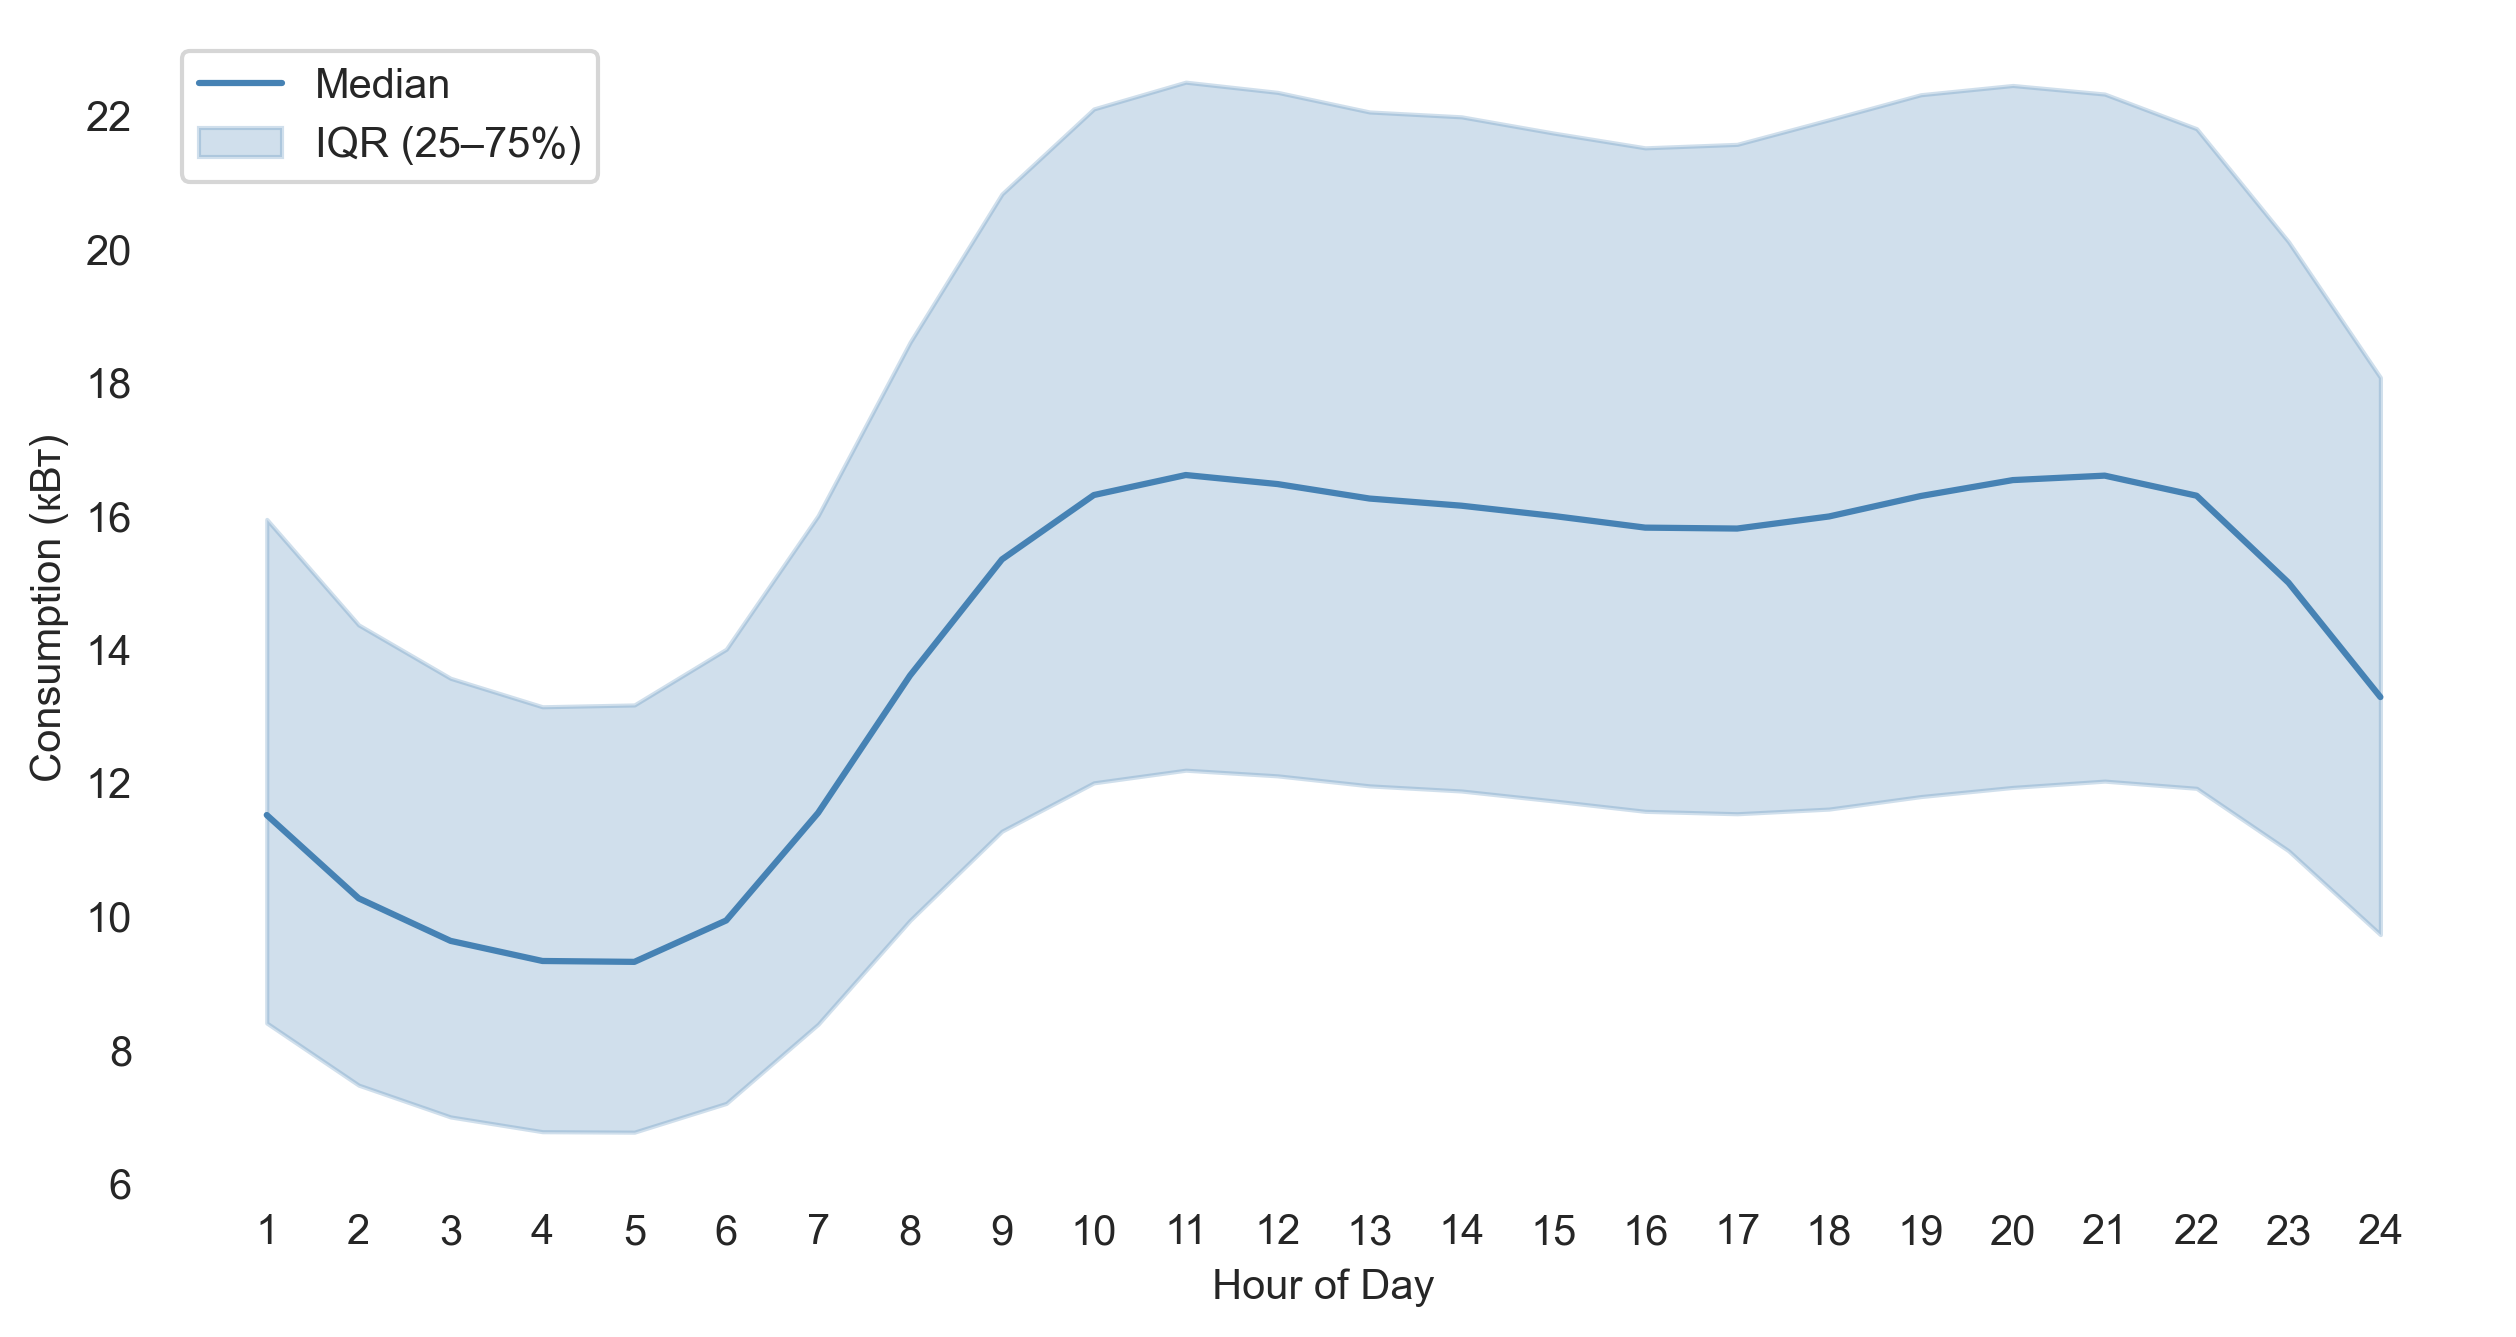

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df = df.copy()
df = df.dropna(subset=['Sum of кВт'])

# hourly aggregation
hourly = df.groupby('Hour')['Sum of кВт']

median = hourly.median()
q1 = hourly.quantile(0.25)
q3 = hourly.quantile(0.75)

hours = median.index

plt.figure(figsize=(10, 5), dpi=300)

# median line
plt.plot(hours, median, color='steelblue', label='Median')

# IQR band
plt.fill_between(
    hours,
    q1,
    q3,
    color='steelblue',
    alpha=0.25,
    label='IQR (25–75%)'
)

# axis labels
plt.xlabel('Hour of Day')
plt.ylabel('Consumption (кВт)')

# styling (match your previous plots)
plt.grid(False)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.legend()

plt.xticks(range(1, 25))

plt.show()

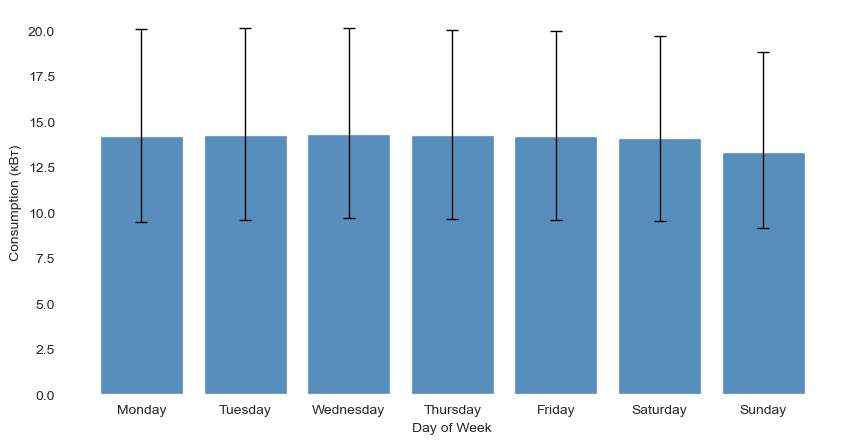

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df['DayOfWeek'] = df['Дата'].dt.day_name()

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

group = df.groupby('DayOfWeek')['Sum of кВт']

median = group.median().reindex(order)
q1 = group.quantile(0.25).reindex(order)
q3 = group.quantile(0.75).reindex(order)

x = np.arange(len(order))
yerr = [median - q1, q3 - median]

plt.figure(figsize=(10, 5))

# median bars
plt.bar(x, median.values, color='steelblue', alpha=0.9)

# IQR error bars
plt.errorbar(
    x,
    median.values,
    yerr=yerr,
    fmt='none',
    ecolor='black',
    capsize=4,
    linewidth=1
)

plt.xlabel('Day of Week')
plt.ylabel('Consumption (кВт)')
plt.xticks(x, order)

plt.grid(False)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

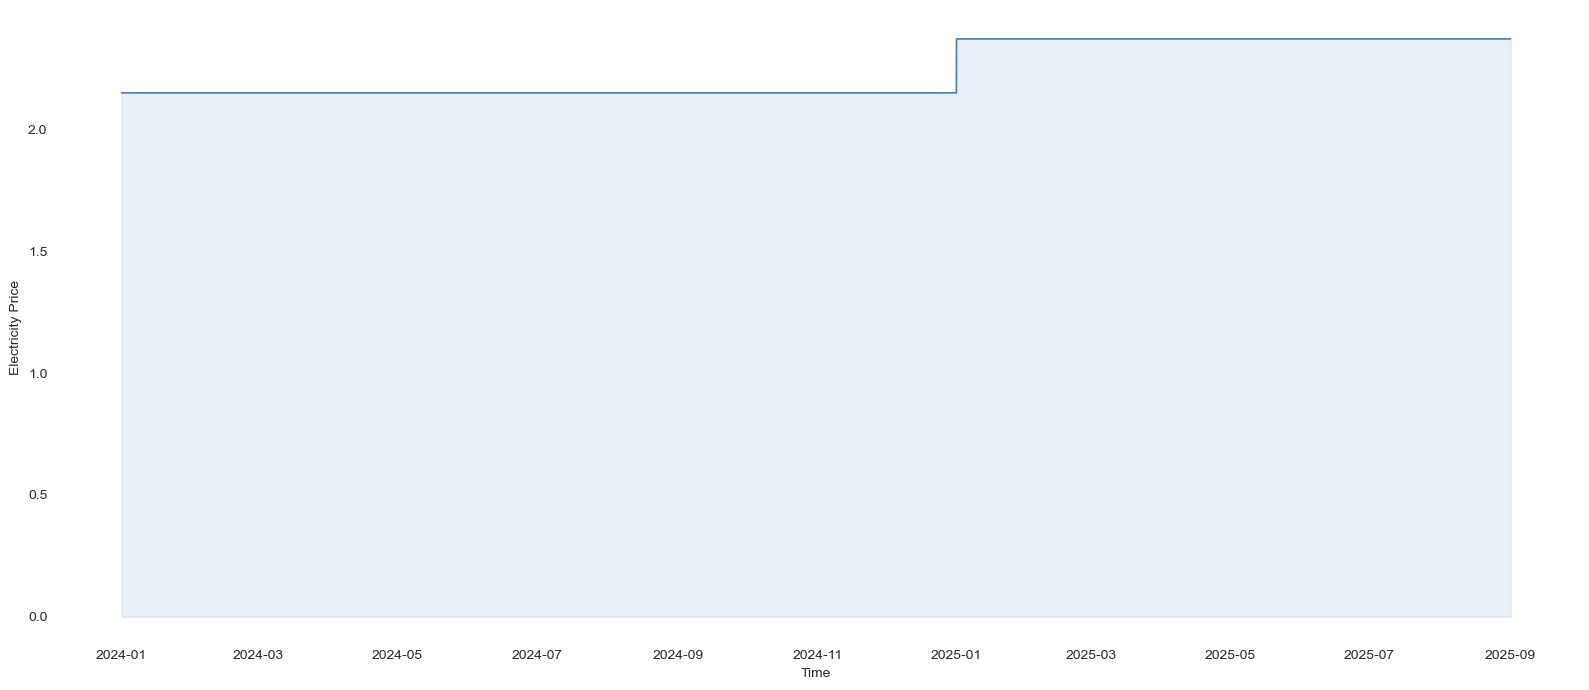

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# --- ensure datetime ---
if not isinstance(df.index, pd.DatetimeIndex):
    if 'Дата' in df.columns:
        df['Дата'] = pd.to_datetime(df['Дата'])
        df = df.sort_values('Дата').set_index('Дата')
    elif 'Timestamp' in df.columns:
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df = df.sort_values('Timestamp').set_index('Timestamp')

df_ = df.dropna(subset=['Average of Ціна ЕЕ грн. без ПДВ/кВт*год'])[df['EIC-код'] == "62Z0008583037334"]

plt.figure(figsize=(16, 7))

# main line
plt.plot(
    df_.index,
    df_['Average of Ціна розподілу ЕЕ грн. без ПДВ/кВт*год'],
    color='steelblue',
    linewidth=1.2
)

# subtle fill for volatility readability
plt.fill_between(
    df_.index,
    df_['Average of Ціна розподілу ЕЕ грн. без ПДВ/кВт*год'],
    color='steelblue',
    alpha=0.12
)

# labels
plt.xlabel("Time")
plt.ylabel("Electricity Price")

# styling (match your theme)
plt.grid(False)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

In [15]:
prices_df = pd.read_excel('data/raw/8month2025.xlsx', sheet_name="ЦіниРДН", header=2)[['Year', 'Month', 'Day', 'Година', 'Average of Ціна, грн без ПДВ/кВт']]

prices_df = prices_df[prices_df['Year'] != 'Grand Total'].copy()

prices_df['Дата'] = pd.to_datetime(
    prices_df[['Year', 'Month', 'Day']].assign(hour=prices_df['Година'])
)
prices_df

,Year,Month,Day,Година,"Average of Ціна, грн без ПДВ/кВт",Дата
0,2024,1.0,1.0,1.0,0.05700,2024-01-01 01:00:00
1,2024,1.0,1.0,2.0,0.05700,2024-01-01 02:00:00
2,2024,1.0,1.0,3.0,0.05555,2024-01-01 03:00:00
3,2024,1.0,1.0,4.0,0.03800,2024-01-01 04:00:00
4,2024,1.0,1.0,5.0,0.03200,2024-01-01 05:00:00
...,...,...,...,...,...,...
15594,2025,10.0,11.0,20.0,14.95073,2025-10-11 20:00:00
15595,2025,10.0,11.0,21.0,14.95057,2025-10-11 21:00:00
15596,2025,10.0,11.0,22.0,14.94907,2025-10-11 22:00:00
15597,2025,10.0,11.0,23.0,14.94767,2025-10-11 23:00:00


In [16]:
# prices_df = prices_df[(prices_df['Дата'] >= "2025-06-01") & (prices_df['Дата'] < "2025-06-08")]

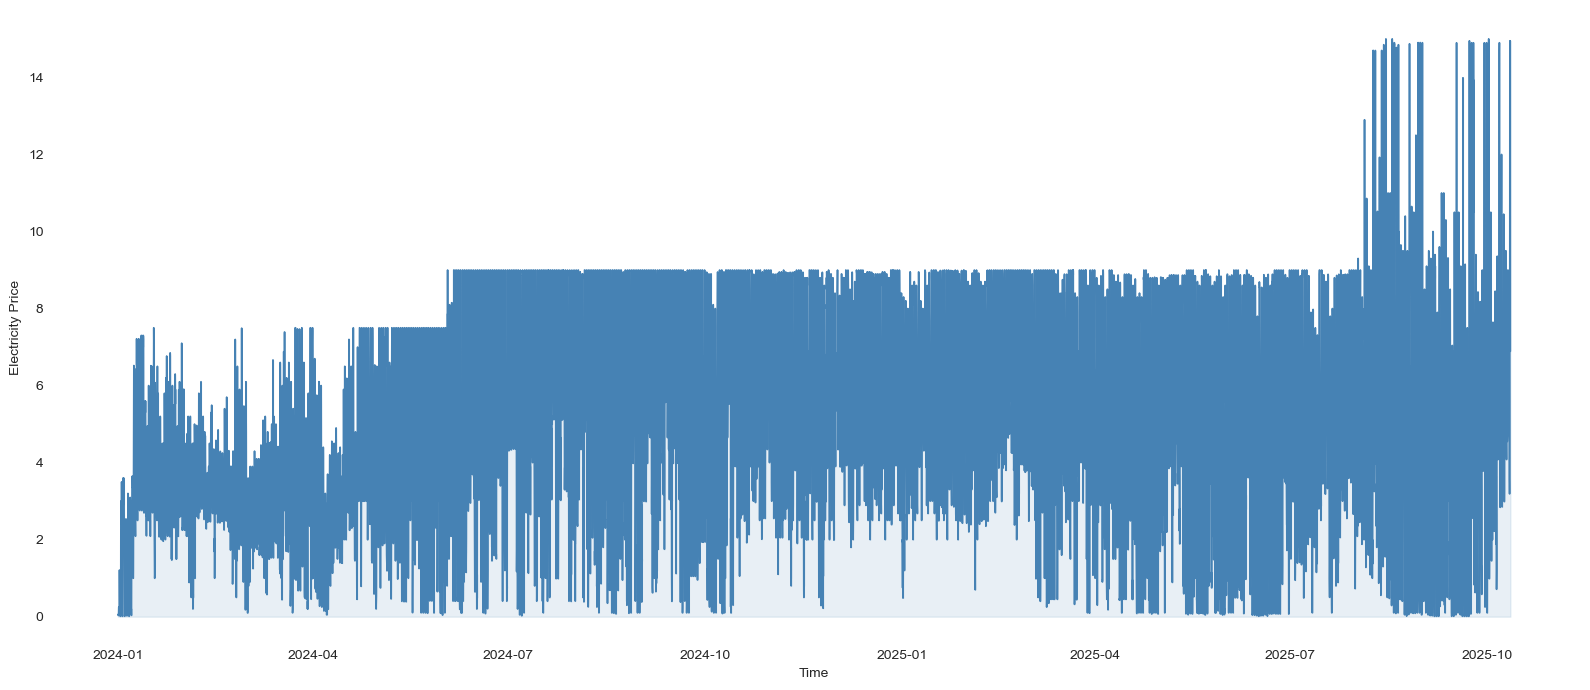

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# --- ensure datetime ---
if not isinstance(prices_df.index, pd.DatetimeIndex):
    if 'Дата' in prices_df.columns:
        prices_df['Дата'] = pd.to_datetime(prices_df['Дата'])
        prices_df = prices_df.sort_values('Дата').set_index('Дата')
    elif 'Timestamp' in prices_df.columns:
        prices_df['Timestamp'] = pd.to_datetime(prices_df['Timestamp'])
        prices_df = prices_df.sort_values('Timestamp').set_index('Timestamp')

prices_df = prices_df.dropna(subset=['Average of Ціна, грн без ПДВ/кВт'])

plt.figure(figsize=(16, 7))

# main line
plt.plot(
    prices_df.index,
    prices_df['Average of Ціна, грн без ПДВ/кВт'],
    color='steelblue',
    linewidth=1.2
)

# subtle fill for volatility readability
plt.fill_between(
    prices_df.index,
    prices_df['Average of Ціна, грн без ПДВ/кВт'],
    color='steelblue',
    alpha=0.12
)

# labels
plt.xlabel("Time")
plt.ylabel("Electricity Price")

# styling (match your theme)
plt.grid(False)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

In [18]:
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import pandas as pd


def plot_consumption_and_price(eval_df, prices_df, eic_code, start_dt=None, end_dt=None):
    # --- consumption ---
    df = eval_df.copy()
    df = df[df['EIC-код'] == eic_code].sort_values("Дата")

    df['Дата'] = pd.to_datetime(df['Дата'])

    if start_dt is not None:
        df = df[df["Дата"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["Дата"] <= pd.Timestamp(end_dt)]

    if df.empty:
        raise ValueError("No consumption data in range")

    # --- prices ---
    prices = prices_df.copy()
    prices['Дата'] = pd.to_datetime(prices['Дата'])
    prices = prices.sort_values('Дата')

    if start_dt is not None:
        prices = prices[prices["Дата"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        prices = prices[prices["Дата"] <= pd.Timestamp(end_dt)]

    prices = prices.dropna(subset=['Average of Ціна, грн без ПДВ/кВт'])

    # --- plot ---
    fig, ax1 = plt.subplots(figsize=(16, 7))

    # --- consumption (left axis) ---
    ax1.plot(
        df["Дата"],
        df['Sum of кВт'],
        color="steelblue",
        linewidth=1.5,
        label="Consumption"
    )

    ax1.fill_between(
        df["Дата"],
        df['Sum of кВт'],
        color="steelblue",
        alpha=0.15
    )

    ax1.set_ylabel("Consumption (кВт)", color="steelblue")
    ax1.set_ylim(bottom=0)

    # --- price (right axis) ---
    ax2 = ax1.twinx()

    ax2.plot(
        prices["Дата"],
        prices['Average of Ціна, грн без ПДВ/кВт'],
        color="green",
        linewidth=1.5,
        label="Price"
    )

    ax2.fill_between(
        prices["Дата"],
        prices['Average of Ціна, грн без ПДВ/кВт'],
        color="green",
        alpha=0
    )

    ax2.set_ylabel("Electricity Price", color="green")

    # --- title ---
    ax1.set_title(
        f"{eic_code}  ({df['Дата'].min().date()} – {df['Дата'].max().date()})",
        pad=12
    )

    # --- x-axis formatting ---
    ax1.set_xlabel("Дата")
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))

    # --- styling (match your theme) ---
    for ax in [ax1, ax2]:
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.tick_params(axis='both', which='both', length=0)

    # --- combined legend ---
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, frameon=False, loc="upper left")

    plt.tight_layout()
    plt.show()


# call
plot_consumption_and_price(
    df,
    prices_df,
    eic_code="62Z3363428137139",
    start_dt="2025-06-01",
    end_dt="2025-06-08"
)

KeyError: 'Дата'

In [31]:
df["median_kwh_by_group"] = (
    df.groupby(["DayOfWeek", "Hour", "EIC-код"])["Sum of кВт"]
      .transform("median")
)

In [32]:
df["counts_by_group"] = (
    df.groupby(["DayOfWeek", "Hour", "EIC-код"])["Sum of кВт"]
      .transform("count")
)

In [46]:
df[
    # (df['Sum of кВт'] <= 5) &
    (df['counts_by_group'] >= 30) &
    (df['Sum of кВт'] < 0.25 * df["median_kwh_by_group"])
][['Sum of кВт', "median_kwh_by_group", "counts_by_group"]]

,Sum of кВт,median_kwh_by_group,counts_by_group
Дата,,,
2024-01-01 01:00:00,0.076081,1.531234,83
2024-01-01 01:00:00,1.777097,9.112957,87
2024-01-01 02:00:00,0.070035,1.380930,83
2024-01-01 02:00:00,1.712557,8.258978,87
2024-01-01 03:00:00,1.621001,7.818724,87
...,...,...,...
2025-08-31 23:00:00,0.144811,1.240943,35
2025-09-01 00:00:00,0.627185,3.868537,82
2025-09-01 00:00:00,0.115849,1.024778,35
